In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("../data/processed/telco_features.csv", index_col="CustomerID")
data = data.drop(columns="Abs Charge Change")
target = "Churn Value"
y = data[target]
X = data.drop(columns=target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train_lin = X_train.drop(columns="Protection Count")
X_test_lin = X_test.drop(columns="Protection Count")

num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
prep = ColumnTransformer([("scale", StandardScaler(), num_cols)], remainder="passthrough")
logit = Pipeline([("prep", prep),
                  ("model", LogisticRegression(class_weight="balanced", max_iter=2000))])
logit.fit(X_train_lin, y_train)

feature_names = num_cols + [c for c in X_train_lin.columns if c not in num_cols]
fitted_prep = logit.named_steps["prep"]
model = logit.named_steps["model"]
X_train_t = pd.DataFrame(fitted_prep.transform(X_train_lin), columns=feature_names, index=X_train_lin.index)
X_test_t = pd.DataFrame(fitted_prep.transform(X_test_lin), columns=feature_names, index=X_test_lin.index)
print(X_test_t.shape)

(1409, 26)


In [2]:
explainer = shap.LinearExplainer(model, X_train_t)
shap_values = explainer.shap_values(X_test_t)

print(shap_values.shape)
print("Base value:", round(float(np.ravel(explainer.expected_value)[0]), 3))
print("Additivity holds:", np.allclose(explainer.expected_value + shap_values.sum(axis=1),
                                        model.decision_function(X_test_t)))

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


(1409, 26)
Base value: -0.764
Additivity holds: True


C:\Users\SWIFT\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Tenure Months                   0.670
Dependents                      0.591
Contract_Two year               0.526
Internet Service_Fiber optic    0.476
Internet Service_No             0.339
Contract_One year               0.294
Tenure Bucket_25-48             0.263
Tenure Bucket_13-24             0.211
dtype: float64


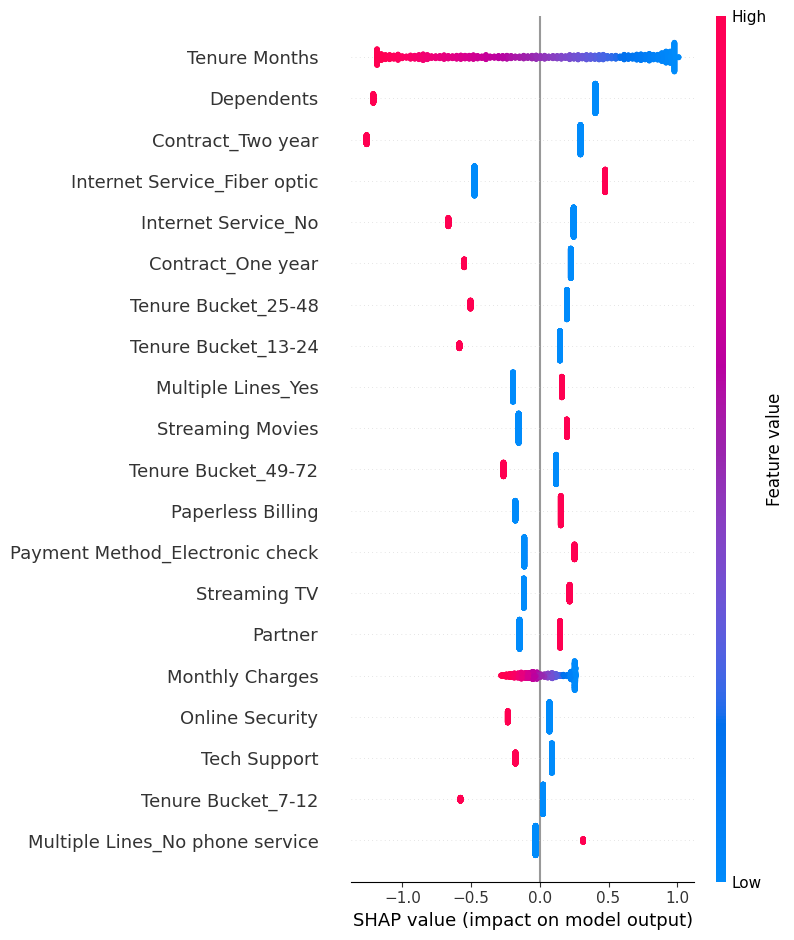

In [3]:
shap_df = pd.DataFrame(shap_values, columns=feature_names, index=X_test_t.index)
print(shap_df.abs().mean().sort_values(ascending=False).head(8).round(3))

shap.summary_plot(shap_values, X_test_t, show=False)
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
GROUPS = {
    "Tenure": ["Tenure Months", "Total Charges", "Tenure Bucket_7-12", "Tenure Bucket_13-24",
               "Tenure Bucket_25-48", "Tenure Bucket_49-72"],
    "Contract": ["Contract_One year", "Contract_Two year"],
    "Internet": ["Internet Service_Fiber optic", "Internet Service_No"],
    "Payment": ["Payment Method_Credit card (automatic)", "Payment Method_Electronic check",
                "Payment Method_Mailed check"],
    "Paperless": ["Paperless Billing"],
    "Security": ["Online Security"],
    "Backup": ["Online Backup"],
    "TechSupport": ["Tech Support"],
    "DeviceProtection": ["Device Protection"],
    "Household": ["Dependents"],
}

used = sum(GROUPS.values(), [])
print("Not used for reasons:", [c for c in feature_names if c not in used])

grouped = pd.DataFrame({g: shap_df[cols].sum(axis=1) for g, cols in GROUPS.items()})

Not used for reasons: ['Monthly Charges', 'Senior Citizen', 'Partner', 'Streaming TV', 'Streaming Movies', 'Multiple Lines_No phone service', 'Multiple Lines_Yes']


In [5]:
def payment_name(x):
    if x["Payment Method_Electronic check"] == 1: return "electronic check"
    if x["Payment Method_Mailed check"] == 1: return "mailed check"
    if x["Payment Method_Credit card (automatic)"] == 1: return "credit card (automatic)"
    return "bank transfer (automatic)"

def reason_text(group, x):
    if group == "Tenure":
        n = int(x["Tenure Months"])
        unit = "month" if n == 1 else "months"
        return f"New customer ({n} {unit})" if n <= 12 else f"Relatively short tenure ({n} {unit})"
    if group == "Contract":
        if x["Contract_Two year"] == 1: return "Two-year contract"
        if x["Contract_One year"] == 1: return "One-year contract (no long-term lock-in)"
        return "Month-to-month contract"
    if group == "Internet":
        if x["Internet Service_Fiber optic"] == 1: return "Fiber optic internet"
        return "No internet service" if x["Internet Service_No"] == 1 else "DSL internet"
    if group == "Payment":     return "Pays by " + payment_name(x)
    if group == "Paperless":   return "Paperless billing"
    if group == "Security":    return "No online security"
    if group == "Backup":      return "No online backup"
    if group == "TechSupport": return "No tech support"
    if group == "DeviceProtection": return "No device protection"
    if group == "Household":   return "No dependents"

def top_reasons(customer_id, n=3):
    row = grouped.loc[customer_id]
    positive = row[row > 0].sort_values(ascending=False).head(n)
    return [reason_text(g, X_test_lin.loc[customer_id]) for g in positive.index]

In [6]:
reasons = {i: top_reasons(i) for i in grouped.index}
reason_df = pd.DataFrame(
    [{"reason_1": (v + [""] * 3)[0], "reason_2": (v + [""] * 3)[1], "reason_3": (v + [""] * 3)[2]}
     for v in reasons.values()],
    index=list(reasons.keys()))

econ = pd.read_csv("../data/processed/economics.csv", index_col="CustomerID")
call_list = econ[["churn_probability", "churn_actual", "CLTV", "Monthly Charges"]].join(reason_df)
print(call_list.shape, (call_list["reason_1"] == "").sum())

call_list.round(4).to_csv("../data/processed/call_list_data.csv")

(1409, 7) 3


In [7]:
top100 = econ.sort_values("ev", ascending=False).head(100).index
all_reasons = pd.concat([call_list.loc[top100, c] for c in ["reason_1", "reason_2", "reason_3"]])
all_reasons[all_reasons != ""].value_counts().head(10)

Month-to-month contract    100
Fiber optic internet        76
No dependents               34
New customer (1 month)      27
New customer (2 months)     16
New customer (3 months)     12
New customer (4 months)      9
New customer (6 months)      6
New customer (9 months)      5
New customer (7 months)      4
Name: count, dtype: int64